# FarrahAI — Notebook 3: Unsupervised Clustering

This notebook demonstrates:
- Clustering OCR text files or labeled topic chunks
- Finding optimal `k` safely using elbow + silhouette
- Saving embeddings in `data/embeddings`
- Visualizing clusters with PCA and dendrogram


In [6]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from modules.embedder import embed_texts
from modules.ml_models import cluster_topics, find_optimal_k

print('Ready')


Ready


## Step 1: Load text samples

You can choose one source:
- OCR files from `data/outputs/ocr_text/AI_ML/*.txt`
- Topic chunk CSV from `data/processed/farrahai_topic_dataset.csv`


In [7]:
DATA_MODE = 'ocr_files'  # 'ocr_files' | 'topic_csv'

texts = []
labels = []

if DATA_MODE == 'ocr_files':
    ocr_dir = Path('../data/outputs/ocr_text/AI_ML')
    files = sorted(ocr_dir.glob('*.txt'))

    for f in files:
        t = f.read_text(encoding='utf-8', errors='ignore').strip()
        if not t:
            continue
        texts.append(t)
        labels.append(f.name)

    print(f'Loaded {len(texts)} OCR text files from: {ocr_dir}')

elif DATA_MODE == 'topic_csv':
    csv_candidates = [
        Path('../data/processed/farrahai_topic_dataset.csv'),
        Path('../data/processed/farrahai_topic_dataset_text_topic.csv'),
        Path('../data/processed/labeled_chunks.csv'),
    ]

    csv_path = None
    for p in csv_candidates:
        if p.exists():
            csv_path = p
            break

    if csv_path is None:
        raise FileNotFoundError('No topic CSV found in expected paths')

    df = pd.read_csv(csv_path)
    if 'text' not in df.columns:
        raise ValueError(f"CSV must include 'text' column. Found: {list(df.columns)}")

    df['text'] = df['text'].astype(str).str.strip()
    df = df[df['text'] != '']

    texts = df['text'].tolist()
    if 'chunk_id' in df.columns:
        labels = df['chunk_id'].astype(str).tolist()
    elif 'topic' in df.columns:
        labels = df['topic'].astype(str).tolist()
    else:
        labels = [f'text_{i:04d}' for i in range(len(df))]

    print(f'Loaded {len(texts)} rows from: {csv_path}')

else:
    raise ValueError("DATA_MODE must be 'ocr_files' or 'topic_csv'")

if len(texts) < 2:
    raise ValueError(f'Need at least 2 text samples for clustering. Found: {len(texts)}')

print('Example label:', labels[0])
print('Example text preview:', texts[0][:160])


Loaded 187 OCR text files from: ../data/outputs/ocr_text/AI_ML
Example label: DECAP737_MACHINE_LEARNING_pages-to-jpg-0001.txt
Example text preview: Machine Learning DECAP737 Edited by Dr. V Devenderan (OVELY | ROFESSIONAL (UNIVERSITY


## Step 2: Generate embeddings and save to `data/embeddings`


In [8]:
print('Generating embeddings (first run may download model ~80MB)...')
embeddings = embed_texts(texts)
print(f'Embeddings shape: {embeddings.shape}')

emb_dir = Path('../data/embeddings')
emb_dir.mkdir(parents=True, exist_ok=True)

emb_npy = emb_dir / 'clustering_embeddings.npy'
meta_csv = emb_dir / 'clustering_embeddings_meta.csv'

np.save(emb_npy, embeddings)
pd.DataFrame({'label': labels, 'text': texts}).to_csv(meta_csv, index=False)

print(f'Saved embeddings: {emb_npy}')
print(f'Saved metadata:   {meta_csv}')


Generating embeddings (first run may download model ~80MB)...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embeddings shape: (187, 384)
Saved embeddings: ../data/embeddings/clustering_embeddings.npy
Saved metadata:   ../data/embeddings/clustering_embeddings_meta.csv


## Step 3: Find optimal `k` (safe range)


n_samples=187, evaluating k in [2, 3, 4, 5, 6, 7, 8, 9]

Best k by silhouette score: 7


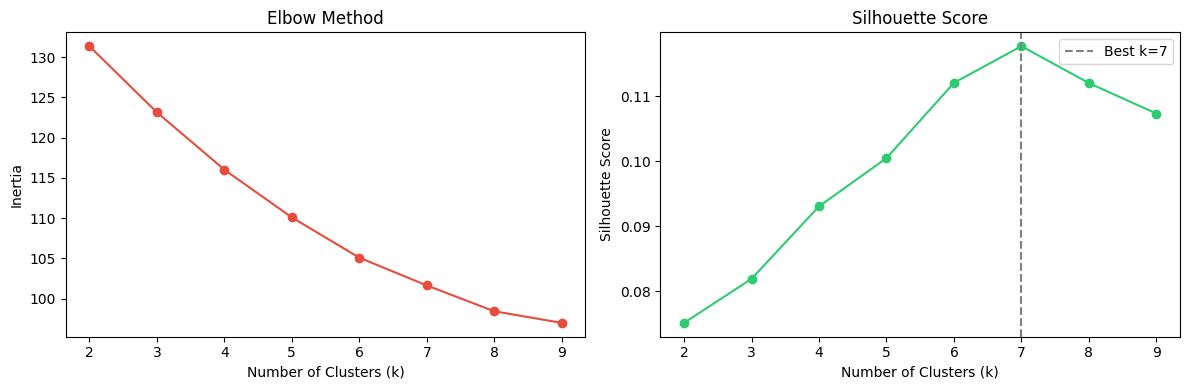

Best k = 7


In [9]:
n_samples = embeddings.shape[0]

# k must be < n_samples
k_max = min(9, n_samples - 1)
if k_max < 2:
    raise ValueError(f'Not enough samples for k>=2. n_samples={n_samples}')

k_range = range(2, k_max + 1)
print(f'n_samples={n_samples}, evaluating k in {list(k_range)}')

k_results = find_optimal_k(embeddings, k_range=k_range)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_results['k_values'], k_results['inertias'], 'o-', color='#e74c3c')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_results['k_values'], k_results['silhouettes'], 'o-', color='#2ecc71')
axes[1].axvline(x=k_results['best_k'], color='gray', linestyle='--', label=f"Best k={k_results['best_k']}")
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/clustering_optimal_k.png', dpi=150)
plt.show()
print(f"Best k = {k_results['best_k']}")


## Step 4: K-Means clustering


In [13]:
best_k = k_results['best_k']
cluster_df = cluster_topics(embeddings, texts, n_clusters=best_k, method='kmeans')
cluster_df['label'] = labels

cluster_out = Path('../outputs/clustering_assignments.csv')
cluster_df.to_csv(cluster_out, index=False)
print(f'Saved: {cluster_out}')

print('\nCluster summary:')
for c in range(best_k):
    group = cluster_df[cluster_df['cluster'] == c]
    print(f"Cluster {c}: {len(group)} items")
    sample = group.head(10)
    for _, row in sample.iterrows():
        print('  -', row['label'])



── Clustering (kmeans, k=7) ────────────
  Silhouette Score: 0.1177  (higher is better, max=1)
Saved: ../outputs/clustering_assignments.csv

Cluster summary:
Cluster 0: 25 items
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0007.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0015.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0016.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0028.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0034.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0035.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0036.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0037.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0038.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0041.txt
Cluster 1: 22 items
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0009.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0163.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0164.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0165.txt
  - DECAP737_MACHINE_LEARNING_pages-to-jpg-0166.txt
  - DECAP737_MACHINE_

## Step 5: 2D visualization (PCA)


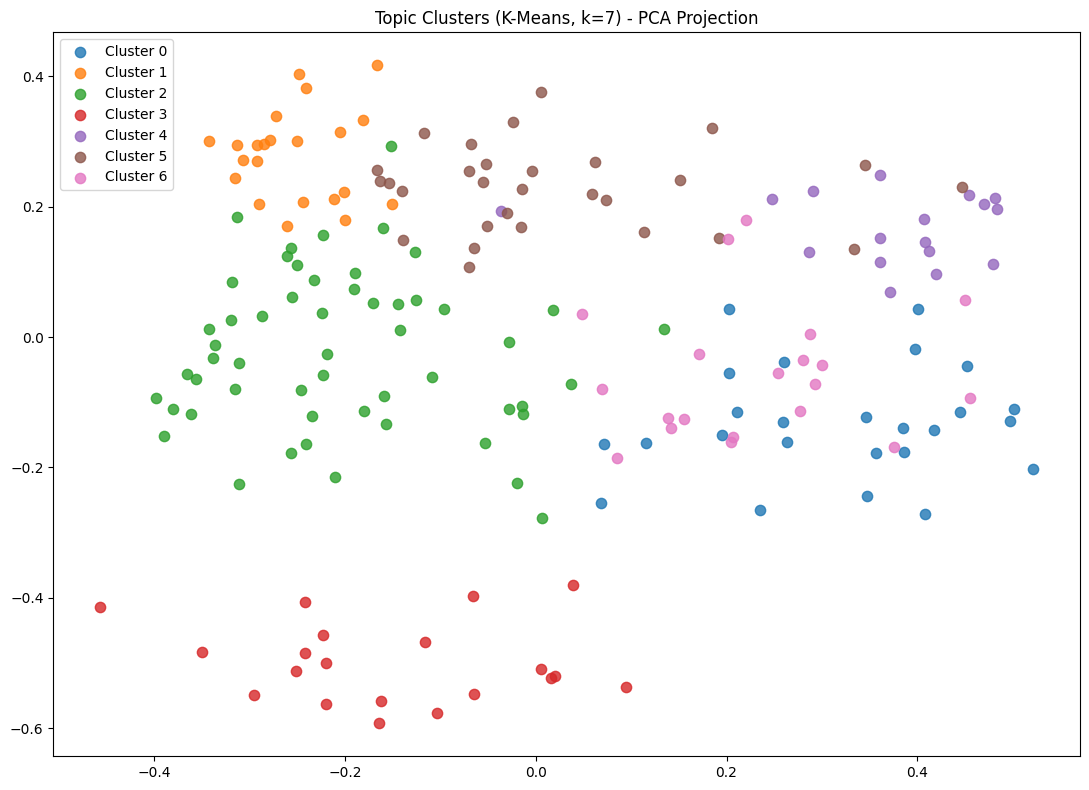

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(11, 8))
for c in range(best_k):
    mask = cluster_df['cluster'].values == c
    ax.scatter(coords[mask, 0], coords[mask, 1], label=f'Cluster {c}', s=55, alpha=0.8)

# annotate only when sample size is manageable
if len(labels) <= 80:
    for i, lab in enumerate(labels):
        ax.annotate(str(lab)[:24], (coords[i, 0], coords[i, 1]), fontsize=6,
                    alpha=0.7, xytext=(0, 5), textcoords='offset points')

ax.set_title(f'Topic Clusters (K-Means, k={best_k}) - PCA Projection')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/clustering_2d_pca.png', dpi=150)
plt.show()


## Step 6: Hierarchical clustering dendrogram


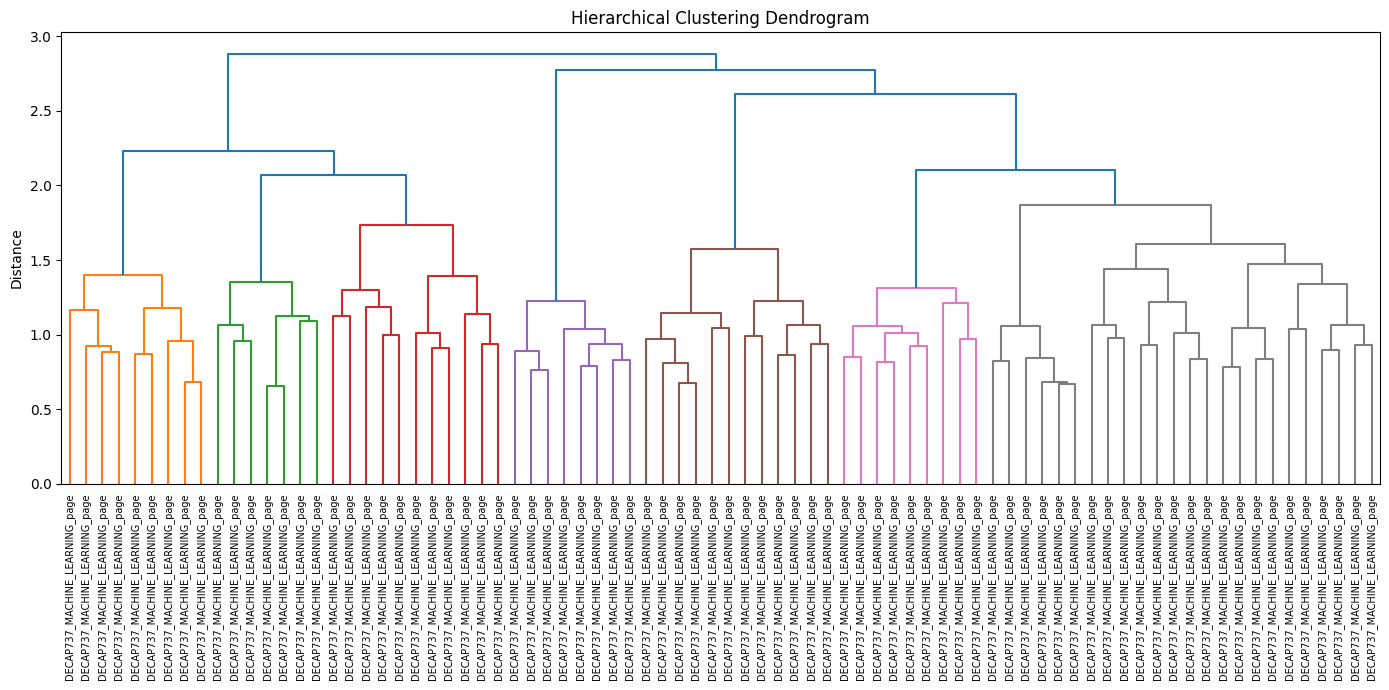

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogram gets crowded; cap for readability
MAX_DENDRO_ITEMS = 80
if len(texts) > MAX_DENDRO_ITEMS:
    idx = np.linspace(0, len(texts) - 1, MAX_DENDRO_ITEMS, dtype=int)
    emb_sub = embeddings[idx]
    lbl_sub = [str(labels[i])[:30] for i in idx]
else:
    emb_sub = embeddings
    lbl_sub = [str(l)[:30] for l in labels]

Z = linkage(emb_sub, method='ward')

fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(Z, labels=lbl_sub, leaf_rotation=90, leaf_font_size=7, ax=ax)
ax.set_title('Hierarchical Clustering Dendrogram')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('../outputs/clustering_dendrogram.png', dpi=150)
plt.show()
